Imported Colab's file uploader, then grabbed two CSV files: the ACS economic characteristics for DC Ward, and the ADA compliance grades file. Just picked them from my computer one after the other.

In [ ]:
from google.colab import files

print("ACS_5-Year_Economic_Characteristics_DC_Ward.csv")
uploaded4 = files.upload()

print("dc_ada_compliance_grades.csv")
uploaded4 = files.upload()

ACS_5-Year_Economic_Characteristics_DC_Ward.csv


Saving ACS_5-Year_Economic_Characteristics_DC_Ward.csv to ACS_5-Year_Economic_Characteristics_DC_Ward.csv
dc_ada_compliance_grades.csv


Saving dc_ada_compliance_grades.csv to dc_ada_compliance_grades.csv


Loaded up my usual libraries—pandas, numpy, matplotlib, seaborn. Then read in both CSV files: the ADA compliance grades and the ACS economic data. Got them into dataframes so I could start playing with the numbers.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ada_df = pd.read_csv('dc_ada_compliance_grades.csv')
acs_df = pd.read_csv('ACS_5-Year_Economic_Characteristics_DC_Ward.csv')

 I Printed the column names and first few rows of both datasets to see their structure. Then I specifically looked for a WARD column in the ADA data and NAMELSAD in the ACS data since those are probably how I'll match them up later.

In [ ]:
print("ADA Data columns:")
print(ada_df.columns.tolist())
print("\nFirst few rows of ADA data:")
print(ada_df.head())

print("\nACS Data columns:")
print(acs_df.columns.tolist())
print("\nFirst few rows of ACS data:")
print(acs_df.head())

print(f"\n'WARD' column exists in ADA data: {'WARD' in ada_df.columns}")
print(f"'NAMELSAD' column exists in ACS data: {'NAMELSAD' in acs_df.columns}")

ADA Data columns:
['WARD', 'Bus_Stops_Count', 'Curb_Ramps_Count', 'APS_Count', 'Barriers_Count', 'Bus_Compliance_Score', 'Curb_Compliance_Score', 'APS_Compliance_Score', 'Barriers_Impact_Score', 'Overall_ADA_Grade', 'Letter_Grade']

First few rows of ADA data:
   WARD  Bus_Stops_Count  Curb_Ramps_Count  APS_Count  Barriers_Count  \
0     8              516              2827        425            1069   
1     6              302              3894       1340             430   
2     7              469              5193        648            2700   
3     2              483              4338       2079             984   
4     1              219              2237        743             513   

   Bus_Compliance_Score  Curb_Compliance_Score  APS_Compliance_Score  \
0             51.817829              46.133711             16.000000   
1             63.867550              44.784797              8.582090   
2             44.426439              32.481417             25.462963   
3           

I pulled the ward number out of the NAMELSAD column—like grabbing the "1" from "Ward 1"—and made it a new column. Then I merged the ADA and ACS datasets using the ward numbers as the key. After that, I checked the merged file size and peeked at a few rows to make sure everything lined up right, looking at the ward, the economic data, and the ADA grade.

In [ ]:
acs_df['ward_number'] = acs_df['NAMELSAD'].str.extract('(\d+)').astype(int)
merged_df = pd.merge(ada_df, acs_df, left_on='WARD', right_on='ward_number')

print(f"Merged dataset shape: {merged_df.shape}")
print(merged_df[['WARD', 'NAMELSAD', 'DP03_0062E', 'Overall_ADA_Grade']].head())

Merged dataset shape: (8, 169)
   WARD NAMELSAD  DP03_0062E  Overall_ADA_Grade
0     8   Ward 8       50931          34.825584
1     6   Ward 6      138047          35.858997
2     7   Ward 7       69109          29.935297
3     2   Ward 2      131405          33.912912
4     1   Ward 1      126387          32.758842


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1011/3488002364.py:2: SyntaxWarning: invalid escape sequence '\d'
  acs_df['ward_number'] = acs_df['NAMELSAD'].str.extract('(\d+)').astype(int)


I checked that the median household income column actually existed, then printed out the income by ward to see what I was working with. Looked for missing values and checked the data type—turns out I needed to convert it to numeric just to be safe, so I did that too.

In [ ]:
print(f"Median Household Income column exists: {'DP03_0062E' in merged_df.columns}")
print("\nMedian Household Income by Ward:")
print(merged_df[['WARD', 'DP03_0062E']].sort_values('WARD'))

print(f"\nMissing values in DP03_0062E: {merged_df['DP03_0062E'].isna().sum()}")
print(f"Data type: {merged_df['DP03_0062E'].dtype}")

merged_df['median_income'] = pd.to_numeric(merged_df['DP03_0062E'], errors='coerce')

Median Household Income column exists: True

Median Household Income by Ward:
   WARD  DP03_0062E
4     1      126387
3     2      131405
6     3      141849
7     4      128210
5     5       97814
1     6      138047
2     7       69109
0     8       50931

Missing values in DP03_0062E: 0
Data type: int64


I grabbed the ADA columns I cared about—bus compliance, curb compliance, APS, barriers impact, and the overall grade. Then I calculated correlations between all those and median household income. Printed out just the income correlations so I could see them clearly. Turns out bus compliance had a decent positive correlation at 0.58, but curb compliance was basically zero and APS was negative. Overall grade was weak at 0.1. Then I made a heatmap to visualize everything—had to rotate the x-axis labels so they wouldn't overlap.

Correlations with Median Household Income:
Bus_Compliance_Score: 0.579
Curb_Compliance_Score: -0.004
APS_Compliance_Score: -0.454
Barriers_Impact_Score: 0.245
Overall_ADA_Grade: 0.096


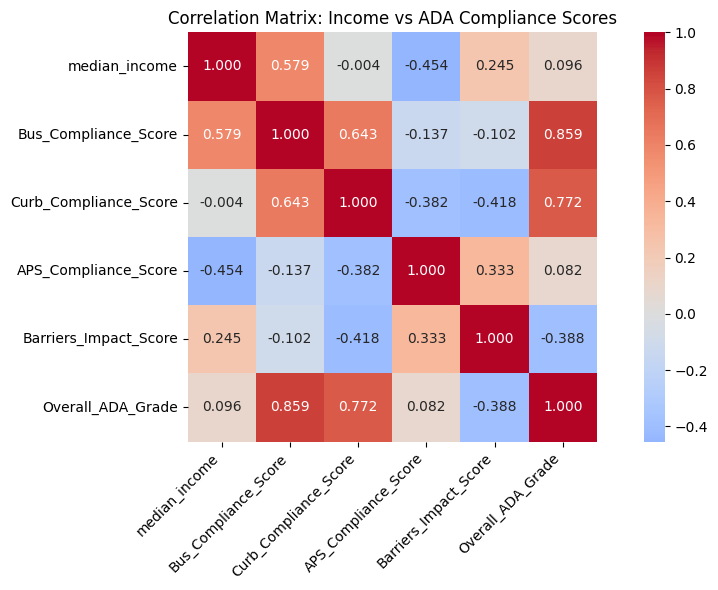

In [ ]:
ada_columns = ['Bus_Compliance_Score', 'Curb_Compliance_Score',
               'APS_Compliance_Score', 'Barriers_Impact_Score', 'Overall_ADA_Grade']

correlation_matrix = merged_df[['median_income'] + ada_columns].corr()

income_correlations = correlation_matrix['median_income'].drop('median_income')
print("Correlations with Median Household Income:")
for col, corr in income_correlations.items():
    print(f"{col}: {corr:.3f}")

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', square=True)

plt.xticks(rotation=45, ha='right')

plt.title('Correlation Matrix: Income vs ADA Compliance Scores')
plt.tight_layout()
plt.show()

I set up a 2x3 grid of scatter plots—one for each ADA metric. Looped through them and plotted median income on the x-axis against each compliance score. Added a red dashed trend line to each so I could see the direction. I Also threw the correlation number right in the title of each plot. Had to delete the extra empty subplot at the end since I only had five metrics, but it gave me a nice visual check of what the numbers were saying.

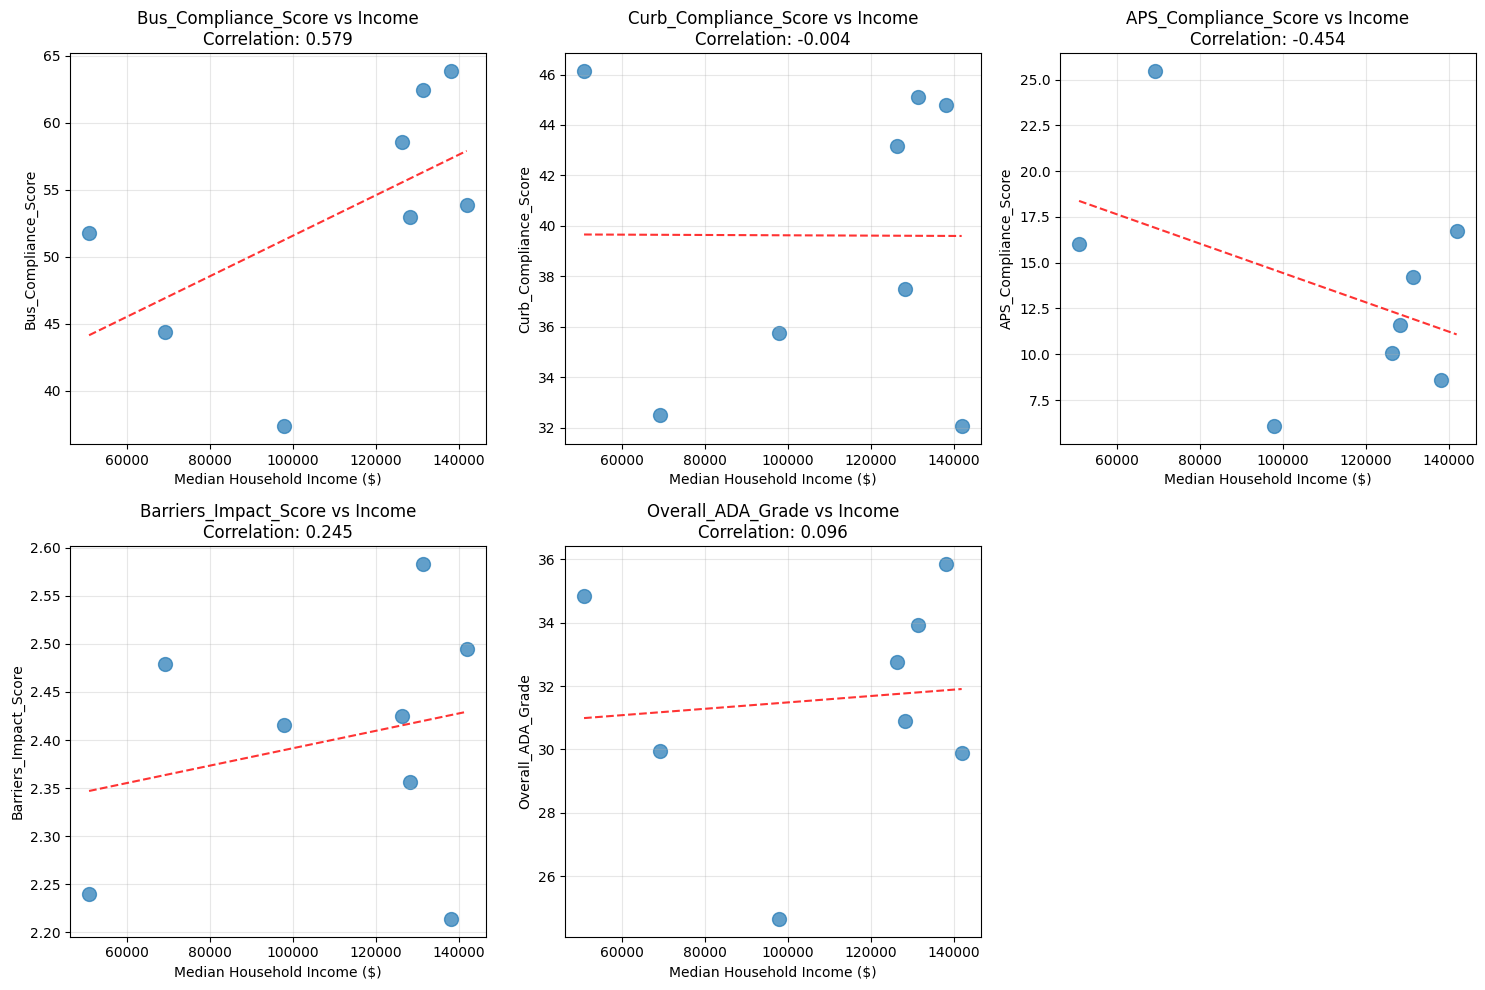

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, metric in enumerate(ada_columns):
    axes[idx].scatter(merged_df['median_income'], merged_df[metric],
                      alpha=0.7, s=100)

    z = np.polyfit(merged_df['median_income'], merged_df[metric], 1)
    p = np.poly1d(z)
    axes[idx].plot(merged_df['median_income'].sort_values(),
                   p(merged_df['median_income'].sort_values()),
                   "r--", alpha=0.8)

    axes[idx].set_xlabel('Median Household Income ($)')
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(f'{metric} vs Income\nCorrelation: {income_correlations[metric]:.3f}')
    axes[idx].grid(True, alpha=0.3)

if len(ada_columns) < 6:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

I grouped everything by ward to get a clean summary table—median income and all the ADA scores for each ward, rounded to two decimals. That made it easy to compare across wards at a glance. Then I ran proper Pearson correlation tests with p-values for each metric, just to be thorough. Bus compliance stayed strong at 0.58, APS still negative around -0.45, and the p-values told me which ones were actually significant.

In [ ]:
ward_summary = merged_df.groupby('WARD').agg({
    'median_income': 'first',
    'Overall_ADA_Grade': 'first',
    'Bus_Compliance_Score': 'first',
    'Curb_Compliance_Score': 'first',
    'APS_Compliance_Score': 'first',
    'Barriers_Impact_Score': 'first'
}).round(2)

print("Summary by Ward:")
print(ward_summary)

from scipy.stats import pearsonr

for metric in ada_columns:
    corr, p_value = pearsonr(merged_df['median_income'].dropna(),
                             merged_df[metric].dropna())
    print(f"{metric}: r={corr:.3f}, p-value={p_value:.4f}")

Summary by Ward:
      median_income  Overall_ADA_Grade  Bus_Compliance_Score  \
WARD                                                           
1            126387              32.76                 58.59   
2            131405              33.91                 62.43   
3            141849              29.88                 53.88   
4            128210              30.89                 52.97   
5             97814              24.65                 37.34   
6            138047              35.86                 63.87   
7             69109              29.94                 44.43   
8             50931              34.83                 51.82   

      Curb_Compliance_Score  APS_Compliance_Score  Barriers_Impact_Score  
WARD                                                                      
1                     43.18                 10.09                   2.42  
2                     45.09                 14.24                   2.58  
3                     32.05               

Uploaded the ACS social characteristics CSV first, then the ADA compliance grades file.

In [ ]:
print("ACS_5-Year_Social_Characteristics_DC_Ward.csv")
uploaded_social = files.upload()

print("dc_ada_compliance_grades.csv")
uploaded_ada= files.upload()

ACS_5-Year_Social_Characteristics_DC_Ward.csv


Saving ACS_5-Year_Social_Characteristics_DC_Ward.csv to ACS_5-Year_Social_Characteristics_DC_Ward.csv
dc_ada_compliance_grades.csv


Saving dc_ada_compliance_grades.csv to dc_ada_compliance_grades (1).csv


I read in both CSV files from the uploads—grabbed the ADA data first, then the social characteristics

In [ ]:
ada_df = pd.read_csv(list(uploaded_ada.keys())[0])
social_df = pd.read_csv(list(uploaded_social.keys())[0])

First I checked what was actually in the ward columns from both datasets—data types and unique values. The ADA dataset had wards as something like numbers, but the social dataset had them as "Ward 1" text. So I renamed both columns to "ward_name" to match, then converted both to strings so they'd play nice together. Did an inner join to keep only wards present in both. Then I extracted the numeric ward number from the name for easier sorting later.
After that, I pulled out the population columns—total population and disabled population—converted them to numbers, and calculated the disability rate as a percentage. Printed a quick preview to make sure everything looked right.

In [ ]:
print("Checking ADA dataset WARD column:")
print(f"Data type: {ada_df['WARD'].dtype}")
print(f"Unique values: {sorted(ada_df['WARD'].unique())}")

print("\nChecking Social dataset NAMELSAD column:")
print(f"Data type: {social_df['NAMELSAD'].dtype}")
print(f"Unique values: {sorted(social_df['NAMELSAD'].unique())}")

ada_df = ada_df.rename(columns={'WARD': 'ward_name'})
social_df = social_df.rename(columns={'NAMELSAD': 'ward_name'})

ada_df['ward_name'] = ada_df['ward_name'].astype(str)
social_df['ward_name'] = social_df['ward_name'].astype(str)

print("\n After converting to string:")
print(f"ADA ward_name type: {ada_df['ward_name'].dtype}")
print(f"ADA values: {sorted(ada_df['ward_name'].unique())}")
print(f"Social ward_name type: {social_df['ward_name'].dtype}")
print(f"Social values: {sorted(social_df['ward_name'].unique())}")

merged_pop_df = pd.merge(ada_df, social_df, on='ward_name', how='inner')


print(f"\n Merged {len(merged_pop_df)} rows")
print(f"Wards in merged dataset: {sorted(merged_pop_df['ward_name'].tolist())}")

merged_pop_df['ward_number'] = merged_pop_df['ward_name'].str.extract('(\d+)').astype(int)
merged_pop_df = merged_pop_df.sort_values('ward_number')


merged_pop_df['total_population'] = pd.to_numeric(merged_pop_df['DP02_0071E'], errors='coerce')
merged_pop_df['disabled_population'] = pd.to_numeric(merged_pop_df['DP02_0072E'], errors='coerce')
merged_pop_df['disability_rate'] = (merged_pop_df['disabled_population'] / merged_pop_df['total_population'] * 100).round(2)

print(f"\n📊 Population Data Loaded:")
print(merged_pop_df[['ward_name', 'total_population', 'disabled_population', 'disability_rate']])


print("\n✅ First few rows of merged dataset:")
print(merged_pop_df[['ward_name', 'total_population', 'Overall_ADA_Grade', 'Bus_Compliance_Score']].head())

Checking ADA dataset WARD column:
Data type: int64
Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Checking Social dataset NAMELSAD column:
Data type: object
Unique values: ['Ward 1', 'Ward 2', 'Ward 3', 'Ward 4', 'Ward 5', 'Ward 6', 'Ward 7', 'Ward 8']

✅ After converting to string:
ADA ward_name type: object
ADA values: ['1', '2', '3', '4', '5', '6', '7', '8']
Social ward_name type: object
Social values: ['Ward 1', 'Ward 2', 'Ward 3', 'Ward 4', 'Ward 5', 'Ward 6', 'Ward 7', 'Ward 8']

✅ Merged 0 rows
Wards in merged dataset: []

📊 Population Data Loaded:
Empty DataFrame
Columns: [ward_name, total_population, disabled_population, disability_rate]
Index: []

✅ First few rows of merged dataset:
Empty DataFrame
Columns: [ward_name, total_population, Overall_ADA_Grade, Bus_Compliance_Score]
Index: []


<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1011/2011398835.py:36: SyntaxWarning: invalid escape sequence '\d'
  merged_pop_df['ward_number'] = merged_pop_df['ward_name'].str.extract('(\d+)').astype(int)


I listed out the ADA metrics I wanted to look at—bus compliance, curb compliance, APS, barriers impact, and overall grade. Then the population metrics—total, disabled, and disability rate. But instead of assuming they were all there, I checked which columns actually existed in my merged dataset. Printed out what I found and how many wards I was working with. Just a quick sanity check before diving into analysis.

In [ ]:
ada_metrics = ['Bus_Compliance_Score', 'Curb_Compliance_Score',
               'APS_Compliance_Score', 'Barriers_Impact_Score', 'Overall_ADA_Grade']

population_metrics = ['total_population', 'disabled_population', 'disability_rate']

existing_ada = [m for m in ada_metrics if m in merged_pop_df.columns]
existing_pop = [p for p in population_metrics if p in merged_pop_df.columns]

print("ADA metrics found:", existing_ada)
print("Population metrics found:", existing_pop)
print(f"Number of wards in analysis: {len(merged_pop_df)}")

ADA metrics found: ['Bus_Compliance_Score', 'Curb_Compliance_Score', 'APS_Compliance_Score', 'Barriers_Impact_Score', 'Overall_ADA_Grade']
Population metrics found: ['total_population', 'disabled_population', 'disability_rate']
Number of wards in analysis: 0


I ran through the same check again—just wanted a clean printout of what columns I actually had in the data. Listed out the ADA metrics and population metrics that existed, showed how many wards I was working with, and printed the actual ward names so I could see which ones made it through the merge. Then I previewed the first three rows to make sure everything looked right—ward name, population numbers, and the first couple ADA scores.

In [ ]:
ada_metrics = ['Bus_Compliance_Score', 'Curb_Compliance_Score',
               'APS_Compliance_Score', 'Barriers_Impact_Score', 'Overall_ADA_Grade']

population_metrics = ['total_population', 'disabled_population', 'disability_rate']

existing_ada = [m for m in ada_metrics if m in merged_pop_df.columns]
existing_pop = [p for p in population_metrics if p in merged_pop_df.columns]

print("="*50)
print("COLUMNS FOUND IN YOUR DATA:")
print("="*50)
print(f"\nADA metrics found: {existing_ada}")
print(f"Population metrics found: {existing_pop}")
print(f"Number of wards: {len(merged_pop_df)}")
print(f"\nWards included: {merged_pop_df['ward_name'].tolist()}")


print("\nFirst 3 rows of key data:")
print(merged_pop_df[['ward_name'] + existing_pop + existing_ada[:2]].head(3))

COLUMNS FOUND IN YOUR DATA:

ADA metrics found: ['Bus_Compliance_Score', 'Curb_Compliance_Score', 'APS_Compliance_Score', 'Barriers_Impact_Score', 'Overall_ADA_Grade']
Population metrics found: ['total_population', 'disabled_population', 'disability_rate']
Number of wards: 0

Wards included: []

First 3 rows of key data:
Empty DataFrame
Columns: [ward_name, total_population, disabled_population, disability_rate, Bus_Compliance_Score, Curb_Compliance_Score]
Index: []


I realized the ADA ward column just had numbers like "1" or "2", while the social dataset had "Ward 1" format. I fixed that by adding "Ward " in front of each ADA ward number. Checked both sides to make sure they matched now—they did. Merged them on ward name, got all eight wards. Pulled out the ward number as a numeric column for sorting, then grabbed total population and disabled population from the ACS columns. Calculated the disability rate as a percentage. Printed a quick preview to make sure everything lined up.

In [ ]:
ada_df['ward_name'] = 'Ward ' + ada_df['ward_name'].astype(str)

print(" After conversion:")
print(f"ADA wards now: {sorted(ada_df['ward_name'].unique())}")
print(f"Social wards: {sorted(social_df['ward_name'].unique())}")

merged_pop_df = pd.merge(ada_df, social_df, on='ward_name', how='inner')

print(f"\n Merge successful! {len(merged_pop_df)} rows merged")
print(f"Wards merged: {sorted(merged_pop_df['ward_name'].tolist())}")

merged_pop_df['ward_number'] = merged_pop_df['ward_name'].str.extract('(\d+)').astype(int)
merged_pop_df = merged_pop_df.sort_values('ward_number')

merged_pop_df['total_population'] = pd.to_numeric(merged_pop_df['DP02_0071E'], errors='coerce')
merged_pop_df['disabled_population'] = pd.to_numeric(merged_pop_df['DP02_0072E'], errors='coerce')
merged_pop_df['disability_rate'] = (merged_pop_df['disabled_population'] / merged_pop_df['total_population'] * 100).round(2)

print("\n First few rows of merged data:")
print(merged_pop_df[['ward_name', 'total_population', 'Overall_ADA_Grade']].head())

✅ After conversion:
ADA wards now: ['Ward 1', 'Ward 2', 'Ward 3', 'Ward 4', 'Ward 5', 'Ward 6', 'Ward 7', 'Ward 8']
Social wards: ['Ward 1', 'Ward 2', 'Ward 3', 'Ward 4', 'Ward 5', 'Ward 6', 'Ward 7', 'Ward 8']

✅ Merge successful! 8 rows merged
Wards merged: ['Ward 1', 'Ward 2', 'Ward 3', 'Ward 4', 'Ward 5', 'Ward 6', 'Ward 7', 'Ward 8']

📊 First few rows of merged data:
  ward_name  total_population  Overall_ADA_Grade
4    Ward 1             78989          32.758842
3    Ward 2             78361          33.912912
6    Ward 3             78111          29.878980
7    Ward 4             85230          30.887660
5    Ward 5             87494          24.653259


<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1011/1929003752.py:16: SyntaxWarning: invalid escape sequence '\d'
  merged_pop_df['ward_number'] = merged_pop_df['ward_name'].str.extract('(\d+)').astype(int)


I looped through each ADA metric and ran a correlation test against disabled population. For each one, I dropped any missing values first, then calculated Pearson's r and the p-value. I added a little logic to label the strength—strong if above 0.7, moderate above 0.5, weak above 0.3, or very weak. Also flagged whether the correlation was positive or negative, and marked significance if the p-value was under 0.05. Printed each result in a clean little block.

In [ ]:
print("\n" + "="*60)
print("📊 DISABLED POPULATION vs ADA Compliance Scores")
print("="*60)

for ada_metric in ada_metrics:
    if ada_metric in merged_pop_df.columns:
        clean_data = merged_pop_df[['disabled_population', ada_metric]].dropna()

        if len(clean_data) > 2:
            pearson_r, pearson_p = pearsonr(clean_data['disabled_population'], clean_data[ada_metric])

            if abs(pearson_r) >= 0.7:
                strength = "Strong"
            elif abs(pearson_r) >= 0.5:
                strength = "Moderate"
            elif abs(pearson_r) >= 0.3:
                strength = "Weak"
            else:
                strength = "Very weak"

            direction = "positive" if pearson_r > 0 else "negative"
            sig = "✅ SIGNIFICANT" if pearson_p < 0.05 else "❌ Not significant"

            print(f"\n{ada_metric}:")
            print(f"  r = {pearson_r:.3f}, p = {pearson_p:.4f}")
            print(f"  → {strength} {direction} correlation - {sig}")


📊 DISABLED POPULATION vs ADA Compliance Scores

Bus_Compliance_Score:
  r = -0.703, p = 0.0518
  → Strong negative correlation - ❌ Not significant

Curb_Compliance_Score:
  r = -0.175, p = 0.6789
  → Very weak negative correlation - ❌ Not significant

APS_Compliance_Score:
  r = 0.450, p = 0.2633
  → Weak positive correlation - ❌ Not significant

Barriers_Impact_Score:
  r = -0.256, p = 0.5406
  → Very weak negative correlation - ❌ Not significant

Overall_ADA_Grade:
  r = -0.245, p = 0.5589
  → Very weak negative correlation - ❌ Not significant


Same thing but this time using disability rate instead of the raw disabled population number. Looped through each ADA metric, ran the Pearson correlation against disability rate, and printed out the r-value, p-value, strength, direction, and significance flag. Wanted to see if the percentage told a different story than the raw counts.

In [ ]:
print("\n" + "="*60)
print("📊 DISABILITY RATE (%) vs ADA Compliance Scores")
print("="*60)

for ada_metric in ada_metrics:
    if ada_metric in merged_pop_df.columns:
        clean_data = merged_pop_df[['disability_rate', ada_metric]].dropna()

        if len(clean_data) > 2:
            pearson_r, pearson_p = pearsonr(clean_data['disability_rate'], clean_data[ada_metric])

            if abs(pearson_r) >= 0.7:
                strength = "Strong"
            elif abs(pearson_r) >= 0.5:
                strength = "Moderate"
            elif abs(pearson_r) >= 0.3:
                strength = "Weak"
            else:
                strength = "Very weak"

            direction = "positive" if pearson_r > 0 else "negative"
            sig = "✅ SIGNIFICANT" if pearson_p < 0.05 else "❌ Not significant"

            print(f"\n{ada_metric}:")
            print(f"  r = {pearson_r:.3f}, p = {pearson_p:.4f}")
            print(f"  → {strength} {direction} correlation - {sig}")


📊 DISABILITY RATE (%) vs ADA Compliance Scores

Bus_Compliance_Score:
  r = -0.669, p = 0.0694
  → Moderate negative correlation - ❌ Not significant

Curb_Compliance_Score:
  r = -0.131, p = 0.7565
  → Very weak negative correlation - ❌ Not significant

APS_Compliance_Score:
  r = 0.457, p = 0.2547
  → Weak positive correlation - ❌ Not significant

Barriers_Impact_Score:
  r = -0.264, p = 0.5281
  → Very weak negative correlation - ❌ Not significant

Overall_ADA_Grade:
  r = -0.201, p = 0.6331
  → Very weak negative correlation - ❌ Not significant
